# 🏎️ Módulo 02: Deep Learning "From Scratch" & El Grafo Computacional
## Capítulo 3: El Zoo de Optimizadores: Dinámicas Físicas, Superficies de Pérdida y de SGD a AdamW

> *"El gradiente nos proporciona una brújula local, pero desconoce la curvatura del terreno. En valles estrechos, mesetas y puntos de silla, seguir ciegamente el gradiente es la receta para el estancamiento. Hoy comprenderemos la física computacional de la optimización moderna: inercia, amortiguamiento y memoria adaptativa."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/02_dl_from_scratch/03_the_optimizer_zoo.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías matemáticas y visuales, y fijamos semillas para garantizar reproducibilidad.

In [1]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict, Callable
import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar la física de los optimizadores")

✅ Entorno listo para estudiar la física de los optimizadores


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### De la Aproximación Estocástica a la Mecánica Newtoniana
* **1951 - Herbert Robbins y Sutton Monro:** Publicaron *"A Stochastic Approximation Method"*, dando a luz al **Descenso de Gradiente Estocástico (SGD)**: en lugar de procesar millones de datos para dar un solo paso, estimamos el gradiente sobre pequeños lotes ruidosos (*mini-batches*).
* **1964 - Boris Polyak y la Bola Pesada (*Heavy Ball Method*):** El matemático soviético Boris Polyak se preguntó: *¿Por qué tratamos a los parámetros como partículas sin masa que se detienen instantáneamente si el gradiente es cero?*
  * Propuso dotar a la optimización de **Momento (inercia física)**: una bola rodando por una ladera acumula velocidad y es capaz de atravesar pequeñas mesetas y oscilaciones ortogonales.
* **1983 - Yurii Nesterov (NAG):** Ideó el *lookahead*: medir el gradiente no en la posición actual, sino en la posición anticipada hacia donde la inercia te está llevando, permitiendo frenar antes de subir la pendiente contraria.

### La Revolución Adaptativa: De AdaGrad a RMSProp
* **2011 - John Duchi et al. (AdaGrad):** Observaron que parámetros con gradientes frecuentes necesitaban pasos pequeños, mientras parámetros poco frecuentes necesitaban pasos grandes. Propusieron dividir el paso por la raíz de la suma histórica de gradientes al cuadrado.
  * **El defecto mortal de AdaGrad:** Al ser una suma monótona acumulativa, el denominador solo crece. En redes neuronales profundas, tras unas pocas épocas el denominador es tan grande que el paso colapsa a cero y el modelo se congela.
* **2012 - Geoffrey Hinton (RMSProp):** En la lección 6e de su curso en Coursera (¡que nunca publicó formalmente en un paper!), Hinton propuso reemplazar la suma monótona por una **Media Móvil Exponencial (EMA)**: olvidar el pasado lejano y mantener una escala móvil de la curvatura reciente.

### El Estándar de la Industria: Adam (2014) y la Corrección de AdamW (2017)
* **2014 - Diederik Kingma y Jimmy Ba (Adam):** Unieron el primer momento (la inercia de Momentum) con el segundo momento (el escalado adaptativo de RMSProp), añadiendo además una corrección matemática de sesgo (*bias correction*) para estabilizar los primeros pasos.
* **2017-2019 - Ilya Loshchilov y Frank Hutter (AdamW):** Descubrieron un grave fallo en cómo todos los frameworks aplicaban regularización $L_2$ con Adam. Demostraron que la regularización debía aplicarse directamente sobre los pesos de forma desacoplada (*Decoupled Weight Decay*). Hoy, **AdamW es el optimizador canónico con el que se entrenan casi todos los Grandes Modelos de Lenguaje (GPT-4, LLaMA, Claude) y Difusores**.

---

## 2. 🧠 Intuición Geométrica y Dinámica Física

### La Patología del Valle Estrecho (Ill-Conditioned Ravines)
Consideremos una función elíptica típica de paisajes de pérdida:
$$f(x, y) = 0.5 x^2 + 10 y^2$$

* El gradiente es $\nabla f = [x, 20y]^T$.
* La curvatura en el eje $y$ es **20 veces mayor** que en el eje $x$.
* En SGD clásico:
  * Si elegimos un learning rate suficientemente grande para avanzar en $x$, en $y$ el paso es excesivo y **rebota violentamente entre las paredes del cañón**.
  * Si reducimos el learning rate para no rebotar en $y$, el avance a lo largo de $x$ hacia el mínimo es dolorosamente lento.

### Las 5 Dinámicas Comparadas:

| Optimizador | Ecuación Central | Mecanismo Físico Clave |
| :--- | :--- | :--- |
| **SGD** | $\theta_{t+1} = \theta_t - \eta g_t$ | Partícula sin masa. Sigue ciegamente el vector local. |
| **Momentum** | $v_t = \beta v_{t-1} + g_t$<br>$\theta_{t+1} = \theta_t - \eta v_t$ | Bola con masa. Las oscilaciones ortogonales se cancelan; la inercia a lo largo del valle se amplifica por $\frac{1}{1-\beta}$. |
| **RMSProp** | $s_t = \beta_2 s_{t-1} + (1-\beta_2) g_t^2$<br>$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t} + \epsilon} g_t$ | Amortiguador adaptativo. Divide por la curvatura: frena en ejes de alto gradiente y acelera en llanuras. |
| **Adam** | $m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$<br>$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$<br>$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}$<br>$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$ | Combina inercia (1º momento) y amortiguamiento por coordenadas (2º momento) con corrección de sesgo inicial. |
| **AdamW** | $\theta_{t+1} = (1 - \eta \lambda) \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$ | **Desacoplamiento:** La contracción de pesos $(1 - \eta \lambda)$ no se deforma por el divisor de curvatura $\sqrt{\hat{v}_t}$. |

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Implementemos los 5 optimizadores como clases modulares en NumPy puro.

In [2]:
class SGDOptimizer:
    def __init__(self, lr: float = 0.01):
        self.lr = lr

    def step(self, w: np.ndarray, grad: np.ndarray) -> np.ndarray:
        return w - self.lr * grad


class MomentumOptimizer:
    def __init__(self, lr: float = 0.01, beta: float = 0.9):
        self.lr = lr
        self.beta = beta
        self.v = None

    def step(self, w: np.ndarray, grad: np.ndarray) -> np.ndarray:
        if self.v is None:
            self.v = np.zeros_like(w)
        # Acumular velocidad con inercia
        self.v = self.beta * self.v + grad
        return w - self.lr * self.v


class RMSpropOptimizer:
    def __init__(self, lr: float = 0.01, beta: float = 0.99, eps: float = 1e-8):
        self.lr = lr
        self.beta = beta
        self.eps = eps
        self.s = None

    def step(self, w: np.ndarray, grad: np.ndarray) -> np.ndarray:
        if self.s is None:
            self.s = np.zeros_like(w)
        # Media móvil exponencial del gradiente al cuadrado
        self.s = self.beta * self.s + (1.0 - self.beta) * (grad ** 2)
        return w - (self.lr / (np.sqrt(self.s) + self.eps)) * grad


class AdamOptimizer:
    def __init__(self, lr: float = 0.01, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0

    def step(self, w: np.ndarray, grad: np.ndarray) -> np.ndarray:
        if self.m is None:
            self.m = np.zeros_like(w)
            self.v = np.zeros_like(w)
        self.t += 1
        
        # Actualización de momentos
        self.m = self.beta1 * self.m + (1.0 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1.0 - self.beta2) * (grad ** 2)
        
        # Corrección de sesgo (bias correction)
        m_hat = self.m / (1.0 - self.beta1 ** self.t)
        v_hat = self.v / (1.0 - self.beta2 ** self.t)
        
        return w - (self.lr / (np.sqrt(v_hat) + self.eps)) * m_hat


class AdamWOptimizer:
    def __init__(self, lr: float = 0.01, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8, weight_decay: float = 0.01):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.m = None
        self.v = None
        self.t = 0

    def step(self, w: np.ndarray, grad: np.ndarray) -> np.ndarray:
        if self.m is None:
            self.m = np.zeros_like(w)
            self.v = np.zeros_like(w)
        self.t += 1
        
        # Momentos calculados SOLO sobre el gradiente de la pérdida pura
        self.m = self.beta1 * self.m + (1.0 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1.0 - self.beta2) * (grad ** 2)
        
        m_hat = self.m / (1.0 - self.beta1 ** self.t)
        v_hat = self.v / (1.0 - self.beta2 ** self.t)
        
        # Desacoplamiento: contracción directa de pesos antes de restar el paso adaptativo
        w_decayed = w * (1.0 - self.lr * self.weight_decay)
        return w_decayed - (self.lr / (np.sqrt(v_hat) + self.eps)) * m_hat

print("✅ 5 Optimizadores From-Scratch compilados exitosamente")

✅ 5 Optimizadores From-Scratch compilados exitosamente


### La Carrera de los Optimizadores en un Paisaje No Convexo de Prueba
Probemos los 5 optimizadores sobre el clásico **Valle de Rosenbrock (la función banana)**:
$$f(x, y) = (1 - x)^2 + 100 (y - x^2)^2$$

El mínimo global está en $(1, 1)$, situado al final de un estrecho cañón parabólico.

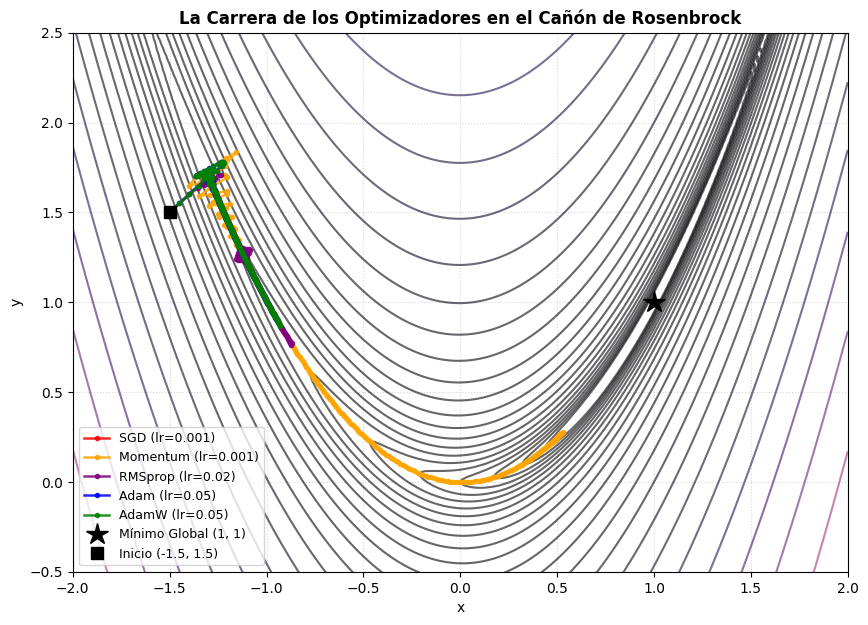

In [3]:
def rosenbrock(w: np.ndarray) -> float:
    x, y = w[0], w[1]
    return (1.0 - x) ** 2 + 100.0 * (y - x ** 2) ** 2

def rosenbrock_grad(w: np.ndarray) -> np.ndarray:
    x, y = w[0], w[1]
    dx = -2.0 * (1.0 - x) - 400.0 * x * (y - x ** 2)
    dy = 200.0 * (y - x ** 2)
    return np.array([dx, dy])

# Simulación comparativa
start_point = np.array([-1.5, 1.5])
n_steps = 250

optimizadores = {
    'SGD (lr=0.001)': SGDOptimizer(lr=0.001),
    'Momentum (lr=0.001)': MomentumOptimizer(lr=0.001, beta=0.85),
    'RMSprop (lr=0.02)': RMSpropOptimizer(lr=0.02, beta=0.99),
    'Adam (lr=0.05)': AdamOptimizer(lr=0.05),
    'AdamW (lr=0.05)': AdamWOptimizer(lr=0.05, weight_decay=0.001)
}

trayectorias = {}
for name, opt in optimizadores.items():
    traj = [start_point.copy()]
    curr_w = start_point.copy()
    for _ in range(n_steps):
        g = rosenbrock_grad(curr_w)
        # Limitar magnitud de gradiente para evitar explosión numérica en Rosenbrock
        g = np.clip(g, -100.0, 100.0)
        curr_w = opt.step(curr_w, g)
        traj.append(curr_w.copy())
    trayectorias[name] = np.array(traj)

# Visualización de curvas de nivel y trayectorias
x_grid = np.linspace(-2.0, 2.0, 250)
y_grid = np.linspace(-1.0, 3.0, 250)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
Z_mesh = (1.0 - X_mesh) ** 2 + 100.0 * (Y_mesh - X_mesh ** 2) ** 2

plt.figure(figsize=(10, 7))
# Dibujar contornos logarítmicos para apreciar los detalles del valle estrecho
plt.contour(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-0.5, 3.5, 25), cmap='magma', alpha=0.6)

colores = {'SGD (lr=0.001)': 'red', 'Momentum (lr=0.001)': 'orange', 'RMSprop (lr=0.02)': 'purple', 'Adam (lr=0.05)': 'blue', 'AdamW (lr=0.05)': 'green'}

for name, traj in trayectorias.items():
    plt.plot(traj[:, 0], traj[:, 1], '-o', label=name, color=colores[name], markersize=3, linewidth=1.8, alpha=0.85)

plt.plot(1.0, 1.0, 'k*', markersize=16, label='Mínimo Global (1, 1)')
plt.plot(start_point[0], start_point[1], 'ks', markersize=8, label='Inicio (-1.5, 1.5)')
plt.title('La Carrera de los Optimizadores en el Cañón de Rosenbrock', fontsize=12, fontweight='bold')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2.0, 2.0)
plt.ylim(-0.5, 2.5)
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

---

## 4. ⚡ Transición a PyTorch Moderno

Verifiquemos que nuestro `AdamWOptimizer` from-scratch produce exactamente la misma trayectoria numérica que `torch.optim.AdamW`:

In [4]:
# 1. Un paso en nuestro AdamW
w_scratch = np.array([2.0, -1.0])
grad_scratch = np.array([0.5, -0.2])
opt_scratch = AdamWOptimizer(lr=0.1, beta1=0.9, beta2=0.999, weight_decay=0.01)
w_scratch_after = opt_scratch.step(w_scratch, grad_scratch)

# 2. Un paso en torch.optim.AdamW
w_torch = torch.tensor([2.0, -1.0], requires_grad=True)
opt_torch = torch.optim.AdamW([w_torch], lr=0.1, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01)
w_torch.grad = torch.tensor([0.5, -0.2])
opt_torch.step()

print(f"AdamW Scratch: {w_scratch_after}")
print(f"AdamW PyTorch: {w_torch.detach().numpy()}")
assert np.allclose(w_scratch_after, w_torch.detach().numpy(), atol=1e-6)
print("\n✅ Coincidencia analítica garantizada: AdamW implementado según el estándar de PyTorch")

AdamW Scratch: [ 1.898 -0.899]
AdamW PyTorch: [ 1.898 -0.899]

✅ Coincidencia analítica garantizada: AdamW implementado según el estándar de PyTorch


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: Escape de Puntos de Silla (Saddle Points)
Consideremos el punto de silla $f(x, y) = x^2 - y^2$, cuyo gradiente en $(0, 0)$ es nulo $[0, 0]$, pero a lo largo de $y$ la función desciende indefinidamente.
Si colocamos una partícula ligeramente desviada en $(0.001, 0.001)$:
* SGD apenas se mueve porque el gradiente es diminuto ($0.002$).
* Momentum acumula inercia y escapa exponencialmente rápido hacia la región de menor energía.

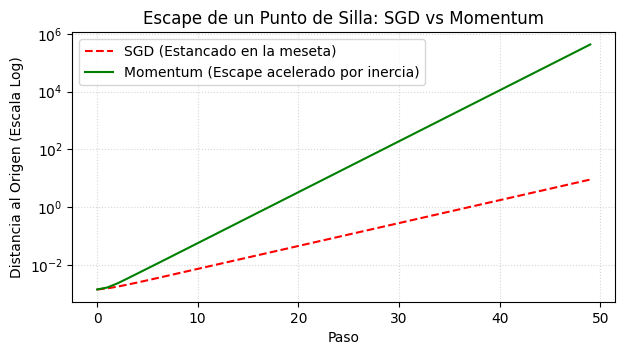

In [5]:
# Experimento de Punto de Silla: f(x, y) = x^2 - y^2
def saddle_grad(w):
    return np.array([2.0 * w[0], -2.0 * w[1]])

w_sgd = np.array([0.001, 0.001])
w_mom = np.array([0.001, 0.001])
opt_s = SGDOptimizer(lr=0.1)
opt_m = MomentumOptimizer(lr=0.1, beta=0.9)

dist_sgd = []
dist_mom = []

for _ in range(50):
    w_sgd = opt_s.step(w_sgd, saddle_grad(w_sgd))
    w_mom = opt_m.step(w_mom, saddle_grad(w_mom))
    dist_sgd.append(np.linalg.norm(w_sgd))
    dist_mom.append(np.linalg.norm(w_mom))

plt.figure(figsize=(7, 3.5))
plt.plot(dist_sgd, 'r--', label='SGD (Estancado en la meseta)')
plt.plot(dist_mom, 'g-', label='Momentum (Escape acelerado por inercia)')
plt.yscale('log')
plt.title('Escape de un Punto de Silla: SGD vs Momentum')
plt.xlabel('Paso')
plt.ylabel('Distancia al Origen (Escala Log)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

### Reto 2 (Para resolver): Implementar Aceleración de Nesterov (NAG)
El método de gradiente acelerado de Nesterov evalúa el gradiente en la posición anticipada $\theta - \beta v_{t-1}$:
$$v_t = \beta v_{t-1} + \nabla f(\theta_t - \beta v_{t-1})$$
$$\theta_{t+1} = \theta_t - \eta v_t$$

Implementa a continuación una clase `NesterovOptimizer` que reciba la función del gradiente o el gradiente proyectado:

In [6]:
# TU CÓDIGO DEL RETO 2 AQUÍ
class NesterovOptimizer:
    def __init__(self, lr: float = 0.01, beta: float = 0.9):
        self.lr = lr
        self.beta = beta
        self.v = None

    def step(self, w: np.ndarray, grad_fn: Callable[[np.ndarray], np.ndarray]) -> np.ndarray:
        """
        Aplica el paso de aceleración de Nesterov evaluando el gradiente en el punto proyectado.
        """
        # Tu implementación aquí
        pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Kingma, D. P., & Ba, J. (2014):** *"Adam: A Method for Stochastic Optimization"*, ICLR 2015. [arXiv:1412.6980](https://arxiv.org/abs/1412.6980)
   * *¿Qué leer?* Sección 2 ("Algorithm") para ver la derivación de la corrección de sesgo para $m_t$ y $v_t$.
2. **Loshchilov, I., & Hutter, F. (2019):** *"Decoupled Weight Decay Regularization"*, ICLR 2019. [arXiv:1711.05101](https://arxiv.org/abs/1711.05101)
   * *¿Qué leer?* La demostración de por qué L2 regularization NO es equivalente a Weight Decay en optimizadores adaptativos.
3. **Polyak, B. T. (1964):** *"Some methods of speeding up the convergence of iteration methods"*, USSR Computational Mathematics and Mathematical Physics, 4(5), 1-17.
   * *¿Qué leer?* La analogía física original de la partícula con masa e inercia.

### 🔗 Artículos Visuales Recomendados
* **Gabriel Goh (Distill.pub):** [Why Momentum Really Works](https://distill.pub/2017/momentum/) - Una de las mejores explicaciones interactivas jamás escritas sobre la física y los autovalores del Momentum.